In [2]:
import os
import math
import copy
import random
import logging
import itertools
import collections
from pathlib import Path
from typing import List

import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import MultiStepLR

import torchvision.transforms as T
import torchvision.transforms.functional as TF

from sklearn.metrics import precision_recall_fscore_support

from vision.ssd.config import mobilenetv1_ssd_config
from vision.ssd.mobilenet_v2_ssd_lite import (
    create_mobilenetv2_ssd_lite,
    create_mobilenetv2_ssd_lite_predictor,
)

In [ ]:
#data set shuold be voc format
dataset_dir = Path('/kaggle/input/flir-voc-uncompressed')
annotation_dir = dataset_dir / 'Annotations'
# annotation should be xml format
dataset_dir_im = Path('/kaggle/input/teledyne-flir-adas-thermal-dataset-v2/FLIR_ADAS_v2/images_thermal_train/data')

dataset_dir_im_test=Path('/kaggle/input/teledyne-flir-adas-thermal-dataset-v2/FLIR_ADAS_v2/images_thermal_val/data')
image_dir = dataset_dir_im

In [ ]:
def load_image(img_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img
def load_labels(annotation_path):
    import xml.etree.ElementTree as ET
    VOC_CLASSES = [
    "background","person","car"
    
]  
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(VOC_CLASSES)}

    tree = ET.parse(annotation_path)
    root = tree.getroot()
    labels = []
    for obj in root.findall('object'):
        class_name = obj.find('name').text.lower().strip()
        if class_name not in class_to_idx:
            continue  # skip unknown class
        class_id = class_to_idx[class_name]

        bbox = obj.find('bndbox')
        xmin = int(float(bbox.find('xmin').text))
        ymin = int(float(bbox.find('ymin').text))
        xmax = int(float(bbox.find('xmax').text))
        ymax = int(float(bbox.find('ymax').text))

        labels.append({
            "class_id": class_id,
            "bbox": [xmin, ymin, xmax, ymax]
        })
    return labels


In [ ]:
class VOCDataset(Dataset):
    def __init__(self, images, annotations, transform=None, target_size=(300,300)):
        self.images = images
        self.annotations = annotations
        self.transform = transform
        self.target_size = target_size  

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]  
        ann = self.annotations[idx]
        if isinstance(img, np.ndarray):
            pil_img = Image.fromarray(img)
        elif isinstance(img, Image.Image):
            pil_img = img
        else:
            pil_img = TF.to_pil_image(img)

        orig_w, orig_h = pil_img.size  
        target_h, target_w = self.target_size  
        if len(ann) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.long)
        else:
            boxes = torch.tensor([obj["bbox"] for obj in ann], dtype=torch.float32)  # [N,4]
            labels = torch.tensor([obj["class_id"] for obj in ann], dtype=torch.long)
            scale_x = target_w / float(orig_w)
            scale_y = target_h / float(orig_h)
            if boxes.numel() > 0:
                boxes[:, [0, 2]] = boxes[:, [0, 2]] * scale_x  # x coords
                boxes[:, [1, 3]] = boxes[:, [1, 3]] * scale_y  # y coords
        if self.transform:
            img_transformed = self.transform(np.array(pil_img))
        else:
            img_transformed = TF.to_tensor(pil_img)

        return img_transformed, boxes, labels

def detection_collate(batch):
    images = []
    boxes = []
    labels = []
    for img, box, label in batch:
        images.append(img)
        boxes.append(box)
        labels.append(label)
    images = torch.stack(images, dim=0)
    return images, boxes, labels
def test_data(x0,x1):
    image_paths= list(dataset_dir_im_test.glob('*.jpg'))[:] 
    images = [load_image(img_path) for img_path in image_paths]
    annotations = [load_labels(annotation_dir / (img_path.stem + '.xml')) for img_path in image_paths]
    transform = T.Compose([
        T.ToPILImage(),                
        T.Resize((300,300)),       
        T.ToTensor()
    ])
    dataset = VOCDataset(images, annotations, transform=transform)
    test_loader = DataLoader(
        dataset,
        batch_size=64,
        collate_fn=detection_collate
    )
    return test_loader

test_loader=test_data(1,2)
print("test_loader",test_loader)


test_loader <torch.utils.data.dataloader.DataLoader object at 0x7b0896f81350>


# train_load 

In [ ]:

def photometric_distort(img):
    """Random brightness, contrast, saturation, hue (PhotometricDistort)."""
    img = np.array(img).astype(np.float32)
    # Random brightness
    if random.random() < 0.5:
        delta = random.uniform(-32, 32)
        img += delta
    # Random contrast
    if random.random() < 0.5:
        alpha = random.uniform(0.5, 1.5)
        img *= alpha

    img = np.clip(img, 0, 255).astype(np.uint8)
    pil_img = Image.fromarray(img, mode='RGB')
    pil_img = T.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05
    )(pil_img)
    return np.array(pil_img).astype(np.float32)
def expand_image(img, boxes, mean):
    """Randomly place the image on a larger canvas (Expand)."""
    if random.random() < 0.5:
        return img, boxes  # skip expansion

    height, width, depth = img.shape
    scale = random.uniform(1, 2)
    new_h = int(height * scale)
    new_w = int(width * scale)

    left = random.randint(0, new_w - width)
    top = random.randint(0, new_h - height)

    expand_img = np.ones((new_h, new_w, depth), dtype=img.dtype) * mean
    expand_img[top:top + height, left:left + width] = img
    img = expand_img

    boxes = boxes.copy()
    boxes[:, [0, 2]] += left
    boxes[:, [1, 3]] += top

    return img, boxes
def random_sample_crop(img, boxes, labels):
    """Randomly crop image keeping IoU overlap."""
    height, width, _ = img.shape
    if boxes.shape[0] == 0:
        return img, boxes, labels

    for _ in range(50):
        new_w = random.uniform(0.3 * width, width)
        new_h = random.uniform(0.3 * height, height)

        if new_h / new_w < 0.5 or new_h / new_w > 2:
            continue

        left = random.uniform(0, width - new_w)
        top = random.uniform(0, height - new_h)

        rect = np.array([int(left), int(top), int(left + new_w), int(top + new_h)])

        # Compute IoU with existing boxes
        overlap = jaccard_numpy(boxes, rect)
        if overlap.max() < 0.1:
            continue

        centers = (boxes[:, :2] + boxes[:, 2:]) / 2.0
        mask = (centers[:, 0] > rect[0]) * (centers[:, 1] > rect[1]) * \
               (centers[:, 0] < rect[2]) * (centers[:, 1] < rect[3])
        if not mask.any():
            continue

        new_boxes = boxes[mask].copy()
        new_labels = labels[mask].copy()

        # Adjust boxes
        new_boxes[:, :2] = np.maximum(new_boxes[:, :2], rect[:2])
        new_boxes[:, 2:] = np.minimum(new_boxes[:, 2:], rect[2:])
        new_boxes[:, :2] -= rect[:2]
        new_boxes[:, 2:] -= rect[:2]

        img = img[int(rect[1]):int(rect[3]), int(rect[0]):int(rect[2]), :]
        return img, new_boxes, new_labels

    return img, boxes, labels


def jaccard_numpy(boxes, rect):
    """Compute IoU between each box and a rectangle."""
    inter_xmin = np.maximum(boxes[:, 0], rect[0])
    inter_ymin = np.maximum(boxes[:, 1], rect[1])
    inter_xmax = np.minimum(boxes[:, 2], rect[2])
    inter_ymax = np.minimum(boxes[:, 3], rect[3])
    inter_area = np.maximum(inter_xmax - inter_xmin, 0) * np.maximum(inter_ymax - inter_ymin, 0)

    box_area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    rect_area = (rect[2] - rect[0]) * (rect[3] - rect[1])
    union_area = box_area + rect_area - inter_area
    return inter_area / np.maximum(union_area, 1e-5)


def random_mirror(img, boxes):
    """Randomly mirror image horizontally."""
    if random.random() < 0.5:
        img = img[:, ::-1, :]
        width = img.shape[1]
        boxes[:, [0, 2]] = width - boxes[:, [2, 0]]
    return img, boxes


def subtract_means(img, mean):
    return img - mean


class VOCDataset(Dataset):
    def __init__(self, images, annotations, mean=(123, 117, 104), size=(300, 300)):
        self.images = images
        self.annotations = annotations
        self.mean = np.array(mean, dtype=np.float32)
        self.size = size  # (h,w)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = np.array(self.images[idx]).astype(np.float32)
        ann = self.annotations[idx]

        boxes = np.array([a["bbox"] for a in ann], dtype=np.float32) if len(ann) else np.zeros((0, 4))
        labels = np.array([a["class_id"] for a in ann], dtype=np.int64) if len(ann) else np.zeros((0,), dtype=np.int64)

        # ----------- Augmentation Pipeline -----------
        img = photometric_distort(img)
        img, boxes = expand_image(img, boxes, self.mean)
        img, boxes, labels = random_sample_crop(img, boxes, labels)
        img, boxes = random_mirror(img, boxes)

        # Resize to final size 300x300
        h, w, _ = img.shape
        img = TF.to_pil_image(img.astype(np.uint8))
        img = TF.resize(img, self.size)
        img = np.array(img).astype(np.float32)

        # Scale boxes
        scale_x = self.size[1] / w
        scale_y = self.size[0] / h
        if boxes.shape[0] > 0:
            boxes[:, [0, 2]] *= scale_x
            boxes[:, [1, 3]] *= scale_y

        img = subtract_means(img, self.mean)
        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.long)

        return img, boxes, labels


def detection_collate(batch):
    images, boxes, labels = [], [], []
    for img, box, label in batch:
        images.append(img)
        boxes.append(box)
        labels.append(label)
    images = torch.stack(images, dim=0)
    return images, boxes, labels
def train_data(x0, x1):
    # Load dataset images and annotations
    image_paths = list(image_dir.glob('*.jpg'))[:]
    images = [load_image(img_path) for img_path in image_paths]
    annotations = [load_labels(annotation_dir / (img_path.stem + '.xml')) for img_path in image_paths]

    # Use the VOCDataset class that already includes all augmentations
    dataset = VOCDataset(
        images,
        annotations,
        mean=(123, 117, 104),
        size=(300, 300)
    )

    train_loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=True, # shuffle for training
        collate_fn=detection_collate
    )
    return train_loader
train_loader = train_data(1, 2)
print("train_loader created successfully with", len(train_loader.dataset), "samples")


train_loader created successfully with 10742 samples


# train_model

In [ ]:
image_size = 300
image_mean = np.array([127, 127, 127])  # RGB layout
image_std = 128.0
iou_threshold = 0.45
center_variance = 0.1
size_variance = 0.2
SSDBoxSizes = collections.namedtuple('SSDBoxSizes', ['min', 'max'])

SSDSpec = collections.namedtuple('SSDSpec', ['feature_map_size', 'shrinkage', 'box_sizes', 'aspect_ratios'])

specs = [
    SSDSpec(19, 16, SSDBoxSizes(16, 32), [2, 3]),
    SSDSpec(10, 32,  SSDBoxSizes(32, 64), [2, 3]),
    SSDSpec(5, 64, SSDBoxSizes(64, 100), [2, 3]),
    SSDSpec(3, 100, SSDBoxSizes(100, 160), [2, 3]),
    SSDSpec(2, 150, SSDBoxSizes(160, 220), [2, 3]),
    SSDSpec(1, 300, SSDBoxSizes(220, 300), [2, 3])
]

def area_of(left_top, right_bottom) -> torch.Tensor:
    """Compute the areas of rectangles given two corners.

    Args:
        left_top (N, 2): left top corner.
        right_bottom (N, 2): right bottom corner.

    Returns:
        area (N): return the area.
    """
    hw = torch.clamp(right_bottom - left_top, min=0.0)
    return hw[..., 0] * hw[..., 1]
def generate_ssd_priors(specs: List[SSDSpec], image_size, clamp=True) -> torch.Tensor:
    priors = []
    for spec in specs:
        scale = image_size / spec.shrinkage
        for j, i in itertools.product(range(spec.feature_map_size), repeat=2):
            x_center = (i + 0.5) / scale
            y_center = (j + 0.5) / scale

            # small sized square box
            size = spec.box_sizes.min
            h = w = size / image_size
            priors.append([
                x_center,
                y_center,
                w,
                h
            ])

            # big sized square box
            size = math.sqrt(spec.box_sizes.max * spec.box_sizes.min)
            h = w = size / image_size
            priors.append([
                x_center,
                y_center,
                w,
                h
            ])

            # change h/w ratio of the small sized box
            size = spec.box_sizes.min
            h = w = size / image_size
            for ratio in spec.aspect_ratios:
                ratio = math.sqrt(ratio)
                priors.append([
                    x_center,
                    y_center,
                    w * ratio,
                    h / ratio
                ])
                priors.append([
                    x_center,
                    y_center,
                    w / ratio,
                    h * ratio
                ])

    priors = torch.tensor(priors)
    if clamp:
        torch.clamp(priors, 0.0, 1.0, out=priors)
    # priors = priors[:-2]
    return priors
def iou_of(boxes0, boxes1, eps=1e-5):
    overlap_left_top = torch.max(boxes0[..., :2], boxes1[..., :2])
    overlap_right_bottom = torch.min(boxes0[..., 2:], boxes1[..., 2:])

    overlap_area = area_of(overlap_left_top, overlap_right_bottom)
    area0 = area_of(boxes0[..., :2], boxes0[..., 2:])
    area1 = area_of(boxes1[..., :2], boxes1[..., 2:])
    return overlap_area / (area0 + area1 - overlap_area + eps)
def center_form_to_corner_form(locations):
    return torch.cat([locations[..., :2] - locations[..., 2:]/2,
                     locations[..., :2] + locations[..., 2:]/2], locations.dim() - 1) 
def corner_form_to_center_form(boxes):
    return torch.cat([
        (boxes[..., :2] + boxes[..., 2:]) / 2,
         boxes[..., 2:] - boxes[..., :2]
    ], boxes.dim() - 1)

def assign_priors(gt_boxes, gt_labels, corner_form_priors,iou_threshold):
    num_priors = corner_form_priors.size(0)
    if gt_boxes.numel() == 0:
        boxes = torch.zeros((num_priors, 4), device=corner_form_priors.device)
        labels = torch.zeros(num_priors, dtype=torch.long, device=corner_form_priors.device)
        return boxes, labels
    # size: num_priors x num_targets
    ious = iou_of(gt_boxes.unsqueeze(0), corner_form_priors.unsqueeze(1))
    # size: num_priors
    best_target_per_prior, best_target_per_prior_index = ious.max(1)
    # size: num_targets
    best_prior_per_target, best_prior_per_target_index = ious.max(0)

    for target_index, prior_index in enumerate(best_prior_per_target_index):
        best_target_per_prior_index[prior_index] = target_index
    # 2.0 is used to make sure every target has a prior assigned
    best_target_per_prior.index_fill_(0, best_prior_per_target_index, 2)
    # size: num_priors
    labels = gt_labels[best_target_per_prior_index]
    labels[best_target_per_prior < iou_threshold] = 0  # the backgournd id
    boxes = gt_boxes[best_target_per_prior_index]
    return boxes, labels

In [7]:
import torch.nn as nn
def hard_negative_mining(loss, labels, neg_pos_ratio):

    pos_mask = labels > 0
    num_pos = pos_mask.long().sum(dim=0, keepdim=True)
    num_neg = num_pos * neg_pos_ratio
    # print("loss",loss.shape)
    # print(num_pos,neg_pos_ratio,num_neg)
    loss[pos_mask] = -math.inf
    _, indexes = loss.sort(dim=0, descending=True)
    _, orders = indexes.sort(dim=0)
    neg_mask = orders < num_neg
    return pos_mask|neg_mask
class MultiboxLoss(nn.Module):
    def __init__(self, priors, iou_threshold, neg_pos_ratio,
                 center_variance, size_variance, device):
        """Implement SSD Multibox Loss.

        Basically, Multibox loss combines classification loss
         and Smooth L1 regression loss.
        """
        super(MultiboxLoss, self).__init__()
        self.iou_threshold = iou_threshold
        self.neg_pos_ratio = neg_pos_ratio
        self.center_variance = center_variance
        self.size_variance = size_variance
        self.priors = priors
        self.priors.to(device)

    def forward(self, confidence, predicted_locations, labels, gt_locations):

        num_classes = 3
        corner_form_priors=center_form_to_corner_form(priors).to(device)
        gt_locations,labels=assign_priors(gt_locations, labels, corner_form_priors,0.7)
        with torch.no_grad():
            loss = -F.log_softmax(confidence, dim=1)[:, 0]
            mask = hard_negative_mining(loss, labels, self.neg_pos_ratio)
            num_selected = mask.sum().item()
        if num_selected ==0:
                # print("yessss")
                classification_loss = F.cross_entropy(confidence.reshape(-1, num_classes), labels, size_average=False)
                # pos_mask = labels > 0
                predicted_locations = predicted_locations.reshape(-1, 4)
                gt_locations = gt_locations.reshape(-1, 4)
                smooth_l1_loss = F.smooth_l1_loss(predicted_locations, gt_locations, size_average=False)
                num_pos = gt_locations.size(0)
                # print("classification_loss",classification_loss)
                return smooth_l1_loss/num_pos, classification_loss/num_pos
        else:
                confidence = confidence[mask, :]
                classification_loss = F.cross_entropy(confidence.reshape(-1, num_classes), labels[mask], size_average=False)
                pos_mask = labels > 0
                predicted_locations = predicted_locations[pos_mask, :].reshape(-1, 4)
                gt_locations = gt_locations[pos_mask, :].reshape(-1, 4)
                smooth_l1_loss = F.smooth_l1_loss(predicted_locations, gt_locations, size_average=False)
                num_pos = gt_locations.size(0)
                return smooth_l1_loss/num_pos, classification_loss/num_pos

In [ ]:
def train(train_loader, val_loader, net, criterion, optimizer, device, epochs=20, save_path="/kaggle/working/"):
    net.to(device)
    best_val_loss = float("inf")  # Initialize best validation loss

    for epoch in range(1, epochs + 1):
        net.train()
        running_loss = 0.0
        running_regression_loss = 0.0
        running_classification_loss = 0.0
        

        for i, data in enumerate(train_loader):
            images, boxes, labels = data
            images = images.to(device)
            boxes = [b.to(device) for b in boxes]
            labels = [l.to(device) for l in labels]

            optimizer.zero_grad()
            confidence, locations = net(images)

            image_width, image_height = 300,300
            gt_boxes_list = [
                b / torch.tensor([image_width, image_height, image_width, image_height], device=device)
                for b in boxes
            ]
            classification_loss = 0.0
            regression_loss = 0.0

            for i in range(len(labels)):
                   regression_loss_, classification_loss_= criterion(confidence[i], locations[i], labels[i], gt_boxes_list[i])
                   classification_loss+=classification_loss_
                   regression_loss+=regression_loss_
            loss = regression_loss+classification_loss
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            running_regression_loss += regression_loss.item()
            running_classification_loss += classification_loss.item()

        print(f"Epoch {epoch}/{epochs}")
        print(f"Train Loss: {running_loss:.4f}, Reg: {running_regression_loss:.4f}, Clf: {running_classification_loss:.4f}")
        print("----" * 20)

        # Validation after each epoch
        if epoch % 5 == 0 :
            net.eval()
            val_loss = 0.0
            val_reg_loss = 0.0
            val_clf_loss = 0.0

            with torch.no_grad():
                for data in val_loader:
                    images, boxes, labels = data
                    images = images.to(device)
                    boxes = [b.to(device) for b in boxes]
                    labels = [l.to(device) for l in labels]

                    gt_boxes_list = [
                        b / torch.tensor([image_width, image_height, image_width, image_height], device=device)
                        for b in boxes
                    ]

                    confidence, locations = net(images)
                    for i in range(len(labels)):
                       regression_loss_, classification_loss_= criterion(confidence[i], locations[i], labels[i], gt_boxes_list[i])
                       classification_loss+=classification_loss_
                       regression_loss+=regression_loss_
                    loss = regression_loss + classification_loss

                    val_loss += loss.item()
                    val_reg_loss += regression_loss.item()
                    val_clf_loss += classification_loss.item()

            print(f"Validation Loss: {val_loss:.4f}, Reg: {val_reg_loss:.4f}, Clf: {val_clf_loss:.4f}")
            print("////" * 20)
            best_val_loss = val_loss
            torch.save(net.state_dict(), f"/kaggle/working/train_1/model_{epoch}.pth")
            print(f"model saved with val_loss: {best_val_loss:.4f}")
            

In [ ]:
model_path_1="/kaggle/input/python-torch-files/model_110_3.pth"
device = torch.device("cuda")
num_classes = 3
model = create_mobilenetv2_ssd_lite(num_classes)
model.load_state_dict(torch.load(model_path_1, map_location=device))
model = model.to(device)
for param in model.parameters():
    param.requires_grad = True

net=model

In [ ]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, net.parameters()),
                       lr=1e-3,  
                       weight_decay=1e-4)
device="cuda"
config = mobilenetv1_ssd_config
priors=generate_ssd_priors(specs, image_size, clamp=True)
criterion = MultiboxLoss(priors, iou_threshold=0.7, neg_pos_ratio=3,center_variance=0.1,size_variance=0.3,device="cuda")
train( train_loader, test_loader, net, criterion, optimizer, device, epochs=180)

/tmp/ipykernel_49/834058752.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil_img = Image.fromarray(img, mode='RGB')
/usr/local/lib/python3.11/dist-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))


# test_model

Image Shape: (512, 640, 3)
Label: tensor(1)
Probability: tensor(1.0000)
Label: tensor(1)
Probability: tensor(0.9989)
Label: tensor(2)
Probability: tensor(0.9954)
Label: tensor(2)
Probability: tensor(0.9794)


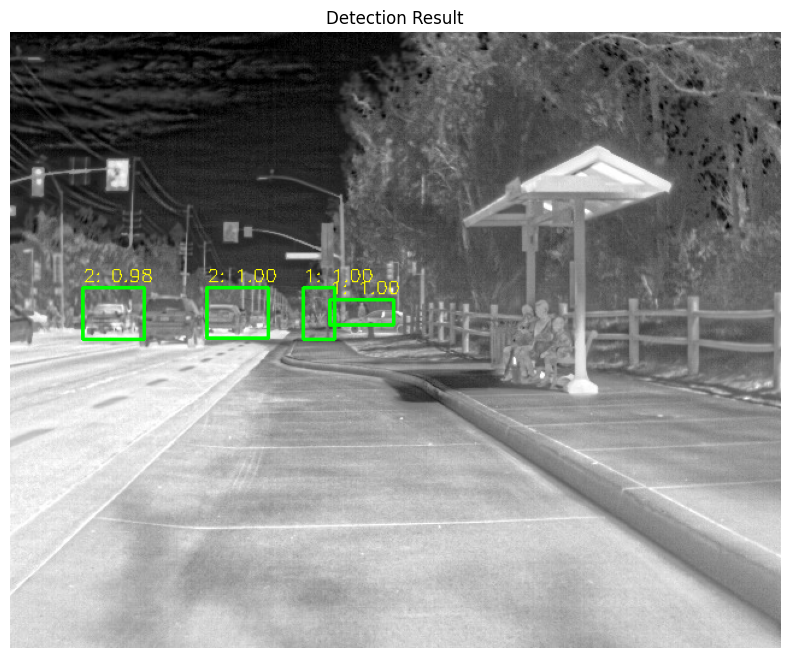

In [ ]:
# =========================================================
# Load Trained MobileNetV2 SSD Lite Model
# =========================================================

model_path = "C:/Users/128/Desktop/Mobilenet.v2_Fine_Tuning/models/model_170_2.pth"

device = torch.device("cpu")
num_classes = 3

model = create_mobilenetv2_ssd_lite(
    num_classes=num_classes,
    is_test=True
)

model.load_state_dict(
    torch.load(model_path, map_location=device)
)

model = model.to(device)

# =========================================================
# Create Predictor
# =========================================================

predictor = create_mobilenetv2_ssd_lite_predictor(
    model,
    candidate_size=20,
    device=device
)

# =========================================================
# Select Test Image
# =========================================================

image_path = r"C:\Users\128\Desktop\Mobilenet.v2_Fine_Tuning\image1.jpg"
img_test = cv2.imread(image_path)
img_test = cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB)
print("Image Shape:", img_test.shape)

# =========================================================
# Run Prediction
# =========================================================

boxes, labels, probs = predictor.predict(
    img_test,
    top_k=2,
    prob_threshold=0.4
)

# =========================================================
# Draw Bounding Boxes
# =========================================================

for i in range(boxes.size(0)):
    box = boxes[i]
    label = labels[i]
    prob = probs[i]

    print("Label:", label)
    print("Probability:", prob)

    cv2.rectangle(
        img_test,
        (int(box[0]), int(box[1])),
        (int(box[2]), int(box[3])),
        (0, 255, 0),
        2
    )

    cv2.putText(
        img_test,
        f"{label}: {prob:.2f}",
        (int(box[0]), int(box[1]) - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 255, 0),
        1
    )

# =========================================================
# Show Result
# =========================================================

plt.figure(figsize=(10, 8))

plt.imshow(img_test)
plt.axis("off")
plt.title("Detection Result")

plt.show()